## Credit Card Fraud Detection
Goal: Build a classification model to identify fraudulent credit card transactions.

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score
from sklearn.metrics import average_precision_score, precision_recall_curve

In [3]:
credit_card_dataset= pd.read_csv("creditcard.csv")

In [4]:
print("Shape:",credit_card_dataset.shape)
print(credit_card_dataset.columns)
credit_card_dataset.head(5)

Shape: (284807, 31)
Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
credit_card_dataset["Class"].value_counts()

,count
Class,
0,284315
1,492


In [6]:
credit_card_dataset["Class"].value_counts() *100 / len(credit_card_dataset)

,count
Class,
0,99.827251
1,0.172749


## Check Missing data

In [7]:
credit_card_dataset.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [8]:
credit_card_dataset.duplicated().sum()

np.int64(1081)

## Checking Duplicated

In [9]:
duplicated_rows = credit_card_dataset[credit_card_dataset.duplicated()]
print(duplicated_rows.shape)
duplicated_rows["Class"].value_counts()

(1081, 31)


,count
Class,
0,1062
1,19


 from the 492 fraud transactions only 3.9% duplicate so we can safely drop the duplicates

In [10]:
credit_card_dataset = credit_card_dataset.drop_duplicates()
print(credit_card_dataset.shape)
print(credit_card_dataset.duplicated().sum())
print(credit_card_dataset["Class"].value_counts())

(283726, 31)
0
Class
0    283253
1       473
Name: count, dtype: int64


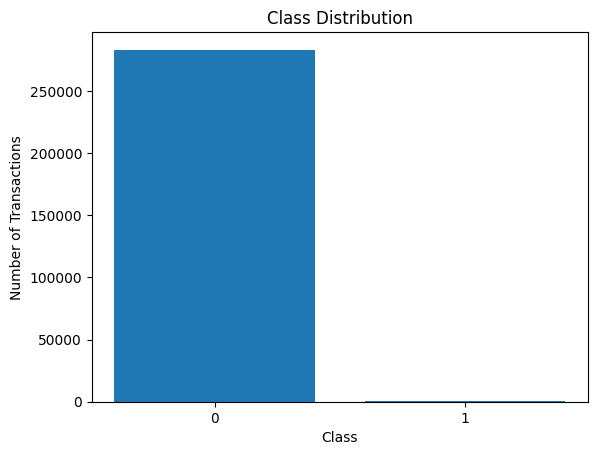

In [11]:
class_counts = credit_card_dataset["Class"].value_counts()
plt.bar(class_counts.index,class_counts.values)
plt.xlabel("Class")
plt.ylabel("Number of Transactions")
plt.title("Class Distribution")
plt.xticks([0, 1])

plt.show()

The dataset is highly imbalanced, with fraudulent transactions representing only about 0.17% of the data. Therefore, accuracy alone will not be a sufficient evaluation metric.

## EDA on Amount

In [12]:
credit_card_dataset.groupby("Class")["Amount"].mean()

,Amount
Class,
0,88.413575
1,123.871860


In [13]:
credit_card_dataset.groupby("Class")["Amount"].median()

,Amount
Class,
0,22.00
1,9.82


In [14]:
credit_card_dataset.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,283253.0,88.413575,250.379023,0.0,5.67,22.00,77.46,25691.16
1,473.0,123.871860,260.211041,0.0,1.00,9.82,105.89,2125.87


Fraud transactions have a higher mean transaction amount, but a lower median, suggesting a skewed distribution with some high-value transactions affecting the mean.

## EDA Time

In [15]:
credit_card_dataset["Hour"] = (credit_card_dataset["Time"] / 3600) % 24
credit_card_dataset.groupby("Class")["Hour"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,283253.0,14.541128,5.843972,0.000000,10.600556,15.011111,19.332222,23.999444
1,473.0,12.148633,6.588707,0.112778,6.579722,12.046944,17.576667,23.993333


## Histogram

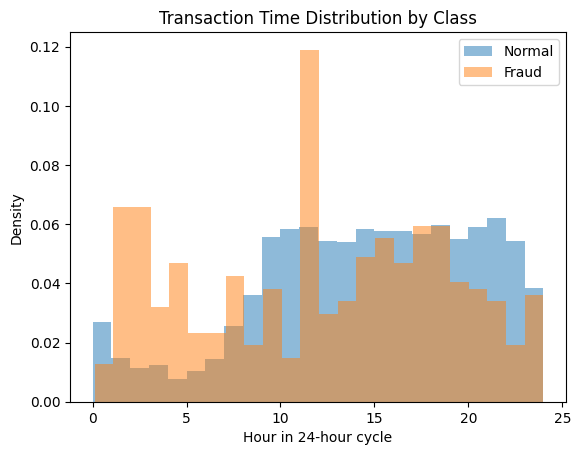

In [16]:
normal_transactions = credit_card_dataset[
    credit_card_dataset["Class"] == 0
]

fraud_transactions = credit_card_dataset[
    credit_card_dataset["Class"] == 1
]
plt.hist(
    normal_transactions["Hour"],
    bins=24,
    alpha=0.5,
    label="Normal",
    density=True
)
## density=True מנרמל כל histogram, כך שאנחנו משווים את צורת ההתפלגות ולא את מספר העסקאות האבסולוטי.
plt.hist(
    fraud_transactions["Hour"],
    bins=24,
    alpha=0.5,
    label="Fraud",
    density=True
)

plt.xlabel("Hour in 24-hour cycle")
plt.ylabel("Density")
plt.title("Transaction Time Distribution by Class")
plt.legend()

plt.show()

The relative time distribution differs between fraudulent and normal transactions, suggesting that Time may contain useful predictive information.

## EDA V1-V28


In [17]:
correlations = credit_card_dataset.corr()

correlations["Class"].abs().sort_values(ascending=False)

,Class
Class,1.000000
V17,0.313498
V14,0.293375
V12,0.250711
V10,0.206971
V16,0.187186
V3,0.182322
V7,0.172347
V11,0.149067
V4,0.129326


In [18]:
credit_card_dataset.groupby("Class")["V17"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,283253.0,0.010963,0.748513,-17.098444,-0.482794,-0.065096,0.399179,9.253526
1,473.0,-6.463285,6.965744,-25.162799,-11.588544,-5.157596,-1.129056,6.739384


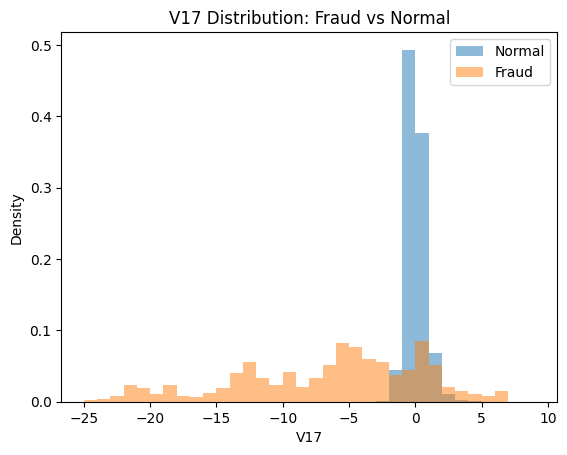

In [19]:
plt.hist(
    normal_transactions["V17"],
    bins=range(-25,10),
    alpha=0.5,
    label="Normal",
    density=True
)
## density=True מנרמל כל histogram, כך שאנחנו משווים את צורת ההתפלגות ולא את מספר העסקאות האבסולוטי.
plt.hist(
    fraud_transactions["V17"],
    bins=range(-25,10),
    alpha=0.5,
    label="Fraud",
    density=True
)

plt.xlabel("V17")
plt.ylabel("Density")
plt.title("V17 Distribution: Fraud vs Normal")
plt.legend()

plt.show()

## Train / Validation / Test split + Stratification.

In [20]:
X= credit_card_dataset.drop(columns=["Class","Hour"])
y = credit_card_dataset["Class"]
X_train ,X_temp, y_train , y_temp = train_test_split(X,y,test_size=0.3, random_state=42,stratify=y)
X_val ,X_test, y_val , y_test = train_test_split(X_temp,y_temp,test_size=0.5, random_state=42,stratify=y_temp)
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

print("\nTrain:")
print(y_train.value_counts())

print("\nValidation:")
print(y_val.value_counts())

print("\nTest:")
print(y_test.value_counts())

(198608, 30)
(42559, 30)
(42559, 30)

Train:
Class
0    198277
1       331
Name: count, dtype: int64

Validation:
Class
0    42488
1       71
Name: count, dtype: int64

Test:
Class
0    42488
1       71
Name: count, dtype: int64


## Baseline and LogisticRegression

In [22]:
baseline_predictions = np.full(y_val.shape, 0) ## Always predict the majority class.
print(baseline_predictions.shape)
baseline_cm = confusion_matrix(y_val, baseline_predictions)

print(baseline_cm)
baseline_accuracy = accuracy_score(y_val, baseline_predictions)
baseline_precision = precision_score(y_val, baseline_predictions)
baseline_recall = recall_score(y_val, baseline_predictions)
print("Baseline Accuracy:", baseline_accuracy)
print("Baseline Precision:", baseline_precision)
print("Baseline Recall:", baseline_recall)


(42559,)
[[42488     0]
 [   71     0]]
Baseline Accuracy: 0.9983317277191663
Baseline Precision: 0.0
Baseline Recall: 0.0


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [25]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression())
])
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression())
])
logistic_model.fit(X_train, y_train)
logistic_predictions = logistic_model.predict(X_val)
print(logistic_predictions.shape)
print(np.unique(logistic_predictions, return_counts=True))
logistic_cm = confusion_matrix(y_val, logistic_predictions)
print(logistic_cm)

(42559,)
(array([0, 1]), array([42517,    42]))
[[42481     7]
 [   36    35]]


In [26]:
logistic_accuracy = accuracy_score(y_val, logistic_predictions)
logistic_precision = precision_score(y_val, logistic_predictions)
logistic_recall = recall_score(y_val, logistic_predictions)

print("Accuracy:", logistic_accuracy)
print("Precision:", logistic_precision)
print("Recall:", logistic_recall)

Accuracy: 0.9989896379144246
Precision: 0.8333333333333334
Recall: 0.49295774647887325


## Classification Threshold

test to see if threshold = 0.3
improves

In [35]:
logistic_probabilities = logistic_model.predict_proba(X_val)
# print(logistic_probabilities.shape)
# print(logistic_probabilities[:5])
fraud_probabilities = logistic_probabilities[:, 1]
threshold = 0.3
predictions_03 = (fraud_probabilities >= threshold).astype(int)
precision_03 = precision_score(y_val, predictions_03)
recall_03 = recall_score(y_val, predictions_03)
cm_03 = confusion_matrix(y_val, predictions_03)

print("Precision:", precision_03)
print("Recall:", recall_03)
print(cm_03)

Precision: 0.7884615384615384
Recall: 0.5774647887323944
[[42477    11]
 [   30    41]]


check for best threshold

In [40]:
thresholds = np.arange(0.01, 0.51, 0.01)

for threshold in thresholds:
    predictions = (fraud_probabilities >= threshold).astype(int)
    f1 = f1_score(y_val, predictions)
    precision = precision_score(y_val, predictions)
    recall = recall_score(y_val, predictions)

    print(
        "Threshold:", threshold,
        "| Precision:", precision,
        "| Recall:", recall,
        "|F1:",f1
    )

Threshold: 0.01 | Precision: 0.472 | Recall: 0.8309859154929577 |F1: 0.6020408163265306
Threshold: 0.02 | Precision: 0.6704545454545454 | Recall: 0.8309859154929577 |F1: 0.7421383647798742
Threshold: 0.03 | Precision: 0.7236842105263158 | Recall: 0.7746478873239436 |F1: 0.7482993197278912
Threshold: 0.04 | Precision: 0.7534246575342466 | Recall: 0.7746478873239436 |F1: 0.7638888888888888
Threshold: 0.05 | Precision: 0.782608695652174 | Recall: 0.7605633802816901 |F1: 0.7714285714285715
Threshold: 0.060000000000000005 | Precision: 0.803030303030303 | Recall: 0.7464788732394366 |F1: 0.7737226277372263
Threshold: 0.06999999999999999 | Precision: 0.803030303030303 | Recall: 0.7464788732394366 |F1: 0.7737226277372263
Threshold: 0.08 | Precision: 0.8125 | Recall: 0.7323943661971831 |F1: 0.7703703703703704
Threshold: 0.09 | Precision: 0.8095238095238095 | Recall: 0.7183098591549296 |F1: 0.7611940298507462
Threshold: 0.09999999999999999 | Precision: 0.8095238095238095 | Recall: 0.7183098591549

In [42]:
pr_auc = average_precision_score(y_val, fraud_probabilities)

print("PR-AUC:", pr_auc)

PR-AUC: 0.6876612934952377


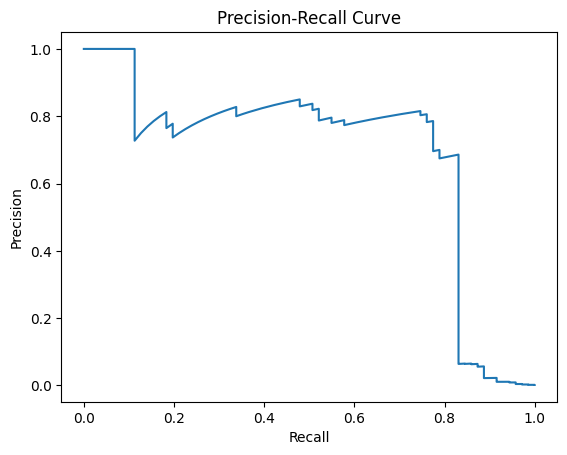

In [44]:
precisions, recalls, thresholds = precision_recall_curve(
    y_val,
    fraud_probabilities
)
plt.plot(recalls, precisions)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

## Logistic Regression With class_weight="balanced"

In [46]:
balanced_logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(class_weight="balanced"))
])
balanced_logistic_model.fit(X_train, y_train)
balanced_predictions = balanced_logistic_model.predict(X_val)
balanced_precision = precision_score(y_val,balanced_predictions)
balanced_f1 = f1_score(y_val, balanced_predictions)
balanced_recall = recall_score(y_val, balanced_predictions)
balanced_cm = confusion_matrix(y_val, balanced_predictions)
print(
        "| Precision:", balanced_precision,
        "| Recall:", balanced_recall,
        "|F1:",balanced_f1
    )
print(balanced_cm)


| Precision: 0.050683829444891394 | Recall: 0.8873239436619719 |F1: 0.0958904109589041
[[41308  1180]
 [    8    63]]


we learn from class_weight="balanced"

During training, it imposes the rule that:

Misclassifying a rare Fraud instance carries a much higher penalty than misclassifying a Normal one.

Consequently, the model becomes far more inclined to predict a transaction as Fraud.

In [51]:
balanced_predictions_prob = balanced_logistic_model.predict_proba(X_val)
balanced_fraud_probabilities = balanced_predictions_prob[:, 1]
balanced_ap = average_precision_score(
    y_val,
    balanced_fraud_probabilities
)

print("Regular Logistic AP:", pr_auc)
print("Balanced Logistic AP:", balanced_ap)

Regular Logistic AP: 0.6876612934952377
Balanced Logistic AP: 0.697147026274304


In [53]:
thresholds = np.arange(0.01, 1.0, 0.01)
for threshold in thresholds:
  predictions = (balanced_fraud_probabilities >= threshold).astype(int)
  f1 = f1_score(y_val, predictions)
  precision = precision_score(y_val, predictions)
  recall = recall_score(y_val, predictions)

  print(
      "Threshold:", threshold,
      "| Precision:", precision,
      "| Recall:", recall,
      "|F1:",f1
  )


Threshold: 0.01 | Precision: 0.00228310502283105 | Recall: 0.9859154929577465 |F1: 0.0045556604080570105
Threshold: 0.02 | Precision: 0.0029377953761655384 | Recall: 0.971830985915493 |F1: 0.0058578826725528485
Threshold: 0.03 | Precision: 0.0036774503011245538 | Recall: 0.971830985915493 |F1: 0.007327174259318254
Threshold: 0.04 | Precision: 0.0044438719649642555 | Recall: 0.971830985915493 |F1: 0.00884728811386075
Threshold: 0.05 | Precision: 0.005215025319325826 | Recall: 0.971830985915493 |F1: 0.010374379792512404
Threshold: 0.060000000000000005 | Precision: 0.0060115002613695765 | Recall: 0.971830985915493 |F1: 0.011949086500995756
Threshold: 0.06999999999999999 | Precision: 0.00680741910023678 | Recall: 0.971830985915493 |F1: 0.013520133241892818
Threshold: 0.08 | Precision: 0.0076091751213056905 | Recall: 0.971830985915493 |F1: 0.015100120363278258
Threshold: 0.09 | Precision: 0.008468335787923416 | Recall: 0.971830985915493 |F1: 0.016790363791215478
Threshold: 0.099999999999999

In [56]:
balanced_precisions, balanced_recalls, balanced_thresholds = precision_recall_curve(
    y_val,
    balanced_fraud_probabilities
)

balanced_f1_scores = (
    2 * balanced_precisions[:-1] * balanced_recalls[:-1]
    / (balanced_precisions[:-1] + balanced_recalls[:-1])
)

best_index = np.argmax(balanced_f1_scores)

best_balanced_threshold = balanced_thresholds[best_index]
best_balanced_precision = balanced_precisions[best_index]
best_balanced_recall = balanced_recalls[best_index]
best_balanced_f1 = balanced_f1_scores[best_index]

print("Best Threshold:", best_balanced_threshold)
print("Precision:", best_balanced_precision)
print("Recall:", best_balanced_recall)
print("F1:", best_balanced_f1)

best_balanced_predictions = (
    balanced_fraud_probabilities >= best_balanced_threshold
).astype(int)

best_balanced_cm = confusion_matrix(
    y_val,
    best_balanced_predictions
)

print(best_balanced_cm)

Best Threshold: 0.9999995008760354
Precision: 0.8870967741935484
Recall: 0.7746478873239436
F1: 0.8270676691729323
[[42481     7]
 [   16    55]]


The threshold that maximized F1 on the validation set was approximately 0.9999995

## Random Forest

In [58]:
from sklearn.ensemble import RandomForestClassifier
random_forest_model = RandomForestClassifier(
    n_estimators=100, # n_estimators=100 — היער מכיל 100 Decision Trees.
    random_state=42,## random_state=42 — מאפשר לנו לקבל תוצאה שחוזרת על עצמה.
    n_jobs=-1 # מאפשר ל־scikit-learn להשתמש בכל ליבות המעבד הזמינות כדי לזרז את האימון.
)

random_forest_model.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [59]:
rf_fraud_probabilities = random_forest_model.predict_proba(X_val)[:, 1]

print(rf_fraud_probabilities.shape)
print(rf_fraud_probabilities[:10])

(42559,)
[0.   0.   0.   0.   0.   0.   0.01 0.   0.   0.  ]


In [60]:
rf_ap = average_precision_score(
    y_val,
    rf_fraud_probabilities
)

print("Random Forest AP:", rf_ap)
print("Regular Logistic AP:", pr_auc)
print("Balanced Logistic AP:", balanced_ap)

Random Forest AP: 0.822211238857961
Regular Logistic AP: 0.6876612934952377
Balanced Logistic AP: 0.697147026274304


Random Forest ranks Fraud transactions much better on the validation set. This is exactly why it was worth testing another algorithm instead of stopping at Logistic Regression.

check at threshold 0.5

In [61]:
rf_predictions = (rf_fraud_probabilities >= 0.5).astype(int)

rf_precision = precision_score(y_val, rf_predictions)
rf_recall = recall_score(y_val, rf_predictions)
rf_f1 = f1_score(y_val, rf_predictions)
rf_cm = confusion_matrix(y_val, rf_predictions)

print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1:", rf_f1)
print(rf_cm)

Precision: 0.9824561403508771
Recall: 0.7887323943661971
F1: 0.875
[[42487     1]
 [   15    56]]


threshold tuning

In [63]:
rf_precisions, rf_recalls, rf_thresholds = precision_recall_curve(
    y_val,
    rf_fraud_probabilities
)

rf_f1_scores = (
    2 * rf_precisions[:-1] * rf_recalls[:-1]
    / (rf_precisions[:-1] + rf_recalls[:-1])
)

best_rf_index = np.argmax(rf_f1_scores)

best_rf_threshold = rf_thresholds[best_rf_index]
best_rf_precision = rf_precisions[best_rf_index]
best_rf_recall = rf_recalls[best_rf_index]
best_rf_f1 = rf_f1_scores[best_rf_index]

print("Best Threshold:", best_rf_threshold)
print("Precision:", best_rf_precision)
print("Recall:", best_rf_recall)
print("F1:", best_rf_f1)

Best Threshold: 0.53
Precision: 0.9824561403508771
Recall: 0.7887323943661971
F1: 0.875


this is currently the best model but we check the model with class_weight="balanced"in case its better

## Random Forest With class_weight="balanced"

In [64]:
balanced_rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

balanced_rf_model.fit(X_train, y_train)

balanced_rf_probabilities = balanced_rf_model.predict_proba(X_val)[:, 1]

balanced_rf_ap = average_precision_score(
    y_val,
    balanced_rf_probabilities
)

print("Regular Random Forest AP:", rf_ap)
print("Balanced Random Forest AP:", balanced_rf_ap)

Regular Random Forest AP: 0.822211238857961
Balanced Random Forest AP: 0.8584388003005758


In [68]:
brf_precisions, brf_recalls, brf_thresholds = precision_recall_curve(
    y_val,
    balanced_rf_probabilities
)
brf_f1_scores = (
    2 * brf_precisions[:-1] * brf_recalls[:-1]
    / (brf_precisions[:-1] + brf_recalls[:-1])
)

best_rf_index = np.argmax(brf_f1_scores)

best_brf_threshold = brf_thresholds[best_rf_index]
best_brf_precision = brf_precisions[best_rf_index]
best_brf_recall = brf_recalls[best_rf_index]
best_brf_f1 = brf_f1_scores[best_rf_index]

print("Best Threshold:", best_brf_threshold)
print("Precision:", best_brf_precision)
print("Recall:", best_brf_recall)
print("F1:", best_brf_f1)
best_brf_predictions = (
    balanced_rf_probabilities >= best_brf_threshold
).astype(int)

print(confusion_matrix(y_val, best_brf_predictions))

Best Threshold: 0.16
Precision: 0.9344262295081968
Recall: 0.8028169014084507
F1: 0.8636363636363635
[[42484     4]
 [   14    57]]


### Regular vs. Balanced Random Forest

* **Regular RF:** 56/71 frauds caught | 1 FP | **F1 = 87.5%**
* **Balanced RF:** 57/71 frauds caught (+1) | 4 FP | **F1 = 86.36%** | **Significantly higher AP**

**Key Takeaways:**
* `class_weight="balanced"` improved ranking (higher AP) and recall, but the higher false positives slightly lowered its peak F1.
* Minimizing False Negatives is vital in fraud detection, but a 1-fraud margin on validation (57 vs. 56) is too small to declare an absolute winner.
* Demonstrates that no single model wins on all metrics; choice depends on business trade-offs.

I chose Balanced Random Forest Model

In [74]:
final_model = balanced_rf_model
final_threshold = best_brf_threshold

print("Final threshold:", final_threshold)

Final threshold: 0.16


Final threshold is 0.16


## Test

In [75]:
test_fraud_probabilities = final_model.predict_proba(X_test)[:, 1]

test_predictions = (
    test_fraud_probabilities >= final_threshold
).astype(int)

In [76]:
test_precision = precision_score(y_test, test_predictions)
test_recall = recall_score(y_test, test_predictions)
test_f1 = f1_score(y_test, test_predictions)

test_ap = average_precision_score(
    y_test,
    test_fraud_probabilities
)

test_cm = confusion_matrix(
    y_test,
    test_predictions
)

print("Final Test Precision:", test_precision)
print("Final Test Recall:", test_recall)
print("Final Test F1:", test_f1)
print("Final Test AP:", test_ap)
print("Final Test Confusion Matrix:")
print(test_cm)

Final Test Precision: 0.8615384615384616
Final Test Recall: 0.7887323943661971
Final Test F1: 0.8235294117647058
Final Test AP: 0.7861386981303251
Final Test Confusion Matrix:
[[42479     9]
 [   15    56]]


### Model Performance: Validation vs. Test

| Metric | Validation | Test |
| :--- | :---: | :---: |
| **Precision** | 93.44% | 86.15% |
| **Recall** | 80.28% | 78.87% |
| **F1** | 86.36% | 82.35% |
| **Average Precision** | 85.84% | 78.61% |

**Key Takeaways:**
* **Generalization:** The model generalizes well to the unseen test set, with only a slight expected drop across metrics.
* **Recall Stability:** Recall remains very consistent (~80.3% vs. ~78.9%), showing the model maintains its ability to catch frauds.
* **Overall Balance:** With an F1 of 82.35% and AP of 78.61% on test, the model demonstrates solid, balanced performance on imbalanced data.

## Feature Importance

In [77]:
feature_importances = balanced_rf_model.feature_importances_
print(feature_importances.shape)
print(feature_importances)

(30,)
[0.00459789 0.01000588 0.04089031 0.08013576 0.09971631 0.00772181
 0.00770524 0.02513598 0.00973524 0.02477481 0.1202712  0.04094394
 0.09775035 0.00657323 0.18712752 0.00622821 0.03929224 0.09281536
 0.0123268  0.01189622 0.00890731 0.01613535 0.0053779  0.00502061
 0.00464967 0.00528914 0.00726632 0.00795091 0.00472436 0.00903414]


In [78]:
feature_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": feature_importances
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_df.head(10)

,Feature,Importance
14,V14,0.187128
10,V10,0.120271
4,V4,0.099716
12,V12,0.097750
17,V17,0.092815
3,V3,0.080136
11,V11,0.040944
2,V2,0.040890
16,V16,0.039292
7,V7,0.025136


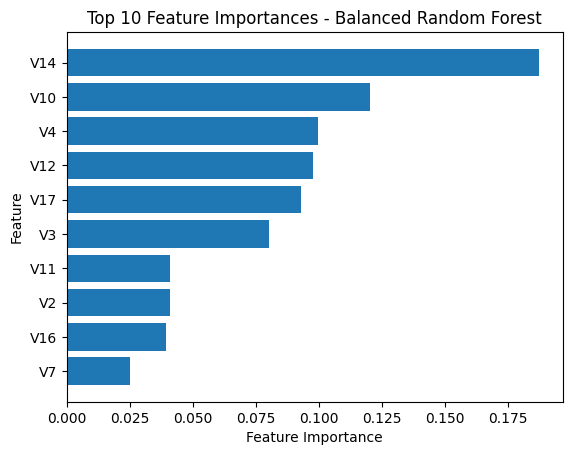

In [82]:
top_features = feature_importance_df.head(10)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances - Balanced Random Forest")

plt.gca().invert_yaxis() # invert_yaxis() simply makes the most important feature appear at the top instead of at the bottom.

plt.show()

This is Random Forest's built-in impurity-based feature importance; therefore, it is useful for understanding the model, but it is not causal proof that V14 "causes" fraud.

## Final Model Comparison

In [83]:
results_df = pd.DataFrame({
    "Model": [
        "Regular Logistic Regression",
        "Balanced Logistic Regression",
        "Random Forest",
        "Balanced Random Forest"
    ],
    "Validation Precision": [
        0.8030,
        0.8871,
        0.9825,
        0.9344
    ],
    "Validation Recall": [
        0.7465,
        0.7746,
        0.7887,
        0.8028
    ],
    "Validation F1": [
        0.7737,
        0.8271,
        0.8750,
        0.8636
    ],
    "Validation AP": [
        pr_auc,
        balanced_ap,
        rf_ap,
        balanced_rf_ap
    ]
})

results_df

,Model,Validation Precision,Validation Recall,Validation F1,Validation AP
0,Regular Logistic Regression,0.8030,0.7465,0.7737,0.687661
1,Balanced Logistic Regression,0.8871,0.7746,0.8271,0.697147
2,Random Forest,0.9825,0.7887,0.8750,0.822211
3,Balanced Random Forest,0.9344,0.8028,0.8636,0.858439


### Model Selection

Random Forest models performed substantially better than Logistic Regression in terms of Average Precision and F1 score.

The Balanced Random Forest achieved the highest validation Average Precision (0.858) and the highest recall among the tested models (0.803). Since missing fraudulent transactions is particularly costly in fraud detection, this model was selected for the final evaluation.

The classification threshold was tuned using the validation set and set to 0.16. The test set was kept untouched during model and threshold selection.

## Final Test Results

* **Precision:** 0.8615
* **Recall:** 0.7887
* **F1:** 0.8235
* **AP:** 0.7861 <br>
Confusion Matrix:<br>
[[42479     9] <br>
 [   15    56]]

## Joblib

In [84]:
import joblib

model_package = {
    "model": balanced_rf_model,
    "threshold": best_brf_threshold
}

joblib.dump(model_package, "credit_card_fraud_model.joblib")

['credit_card_fraud_model.joblib']